In [1]:
import pandas as pd
df_trained = pd.read_csv(r'C:\Users\Lenovo\Downloads\final_merged_sleep_lifestyle.csv')

In [4]:
# -------------------------
# Import required libraries
# -------------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------
# Select features and target
# -------------------------
X = df_trained[[
    "Heart Rate_mean",
    "Sleep Duration_mean"
]]

y = df_trained["Stress Level_mean"]

# -------------------------
# Train-test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# Train Linear Regression
# -------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

# -------------------------
# Predict + Evaluate
# -------------------------
y_pred = lr.predict(X_test)

print("Linear Regression Results")
print("--------------------------")
print("Coefficients:", lr.coef_)
print("Intercept:", lr.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


Linear Regression Results
--------------------------
Coefficients: [ 0.11411443 -1.33637933]
Intercept: 6.8419237718495864
MSE: 0.34143754808497856
R² Score: 0.747151741322118



Random Forest Results
--------------------------
MSE: 0.6123847547222253
R² Score: 0.5465044200883871


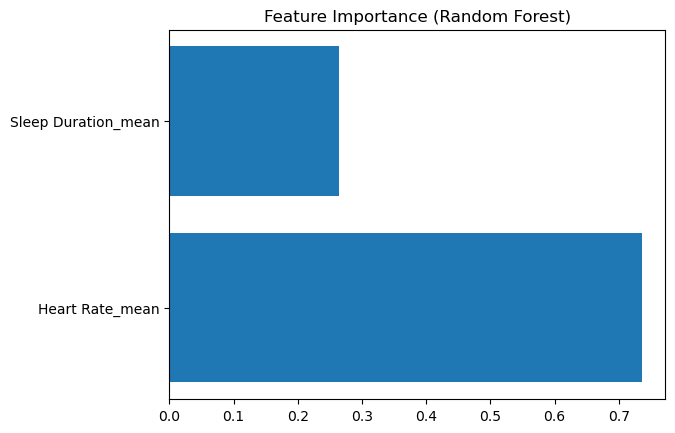

In [5]:
# -------------------------
# Import Random Forest
# -------------------------
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# Same features and target
# -------------------------
X = df_trained[[
    "Heart Rate_mean",
    "Sleep Duration_mean",
]]

y = df_trained["Stress Level_mean"]

# -------------------------
# Train-test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# Train Random Forest
# -------------------------
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

# -------------------------
# Predict + Evaluate
# -------------------------
y_pred = rf.predict(X_test)

print("\nRandom Forest Results")
print("--------------------------")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# -------------------------
# Feature Importance
# -------------------------
import matplotlib.pyplot as plt

importances = rf.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()
